# Credit Scoring Model

## Objective

To predict whether a customer is creditworthy using a Random Forest Classifier.

## Import Libraries

## Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("german_credit_data.csv")
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## Check Missing Values

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


,0
laufkont,0
laufzeit,0
moral,0
verw,0
hoehe,0
sparkont,0
beszeit,0
rate,0
famges,0
buerge,0


## Separate Features and Target

In [3]:
X = df.drop("kredit", axis=1)
y = df["kredit"]

## Split Dataset

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Train Random Forest Model

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Predict Test Data

In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.735


## Evaluate Model

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.60      0.42      0.50        62
           1       0.77      0.88      0.82       138

    accuracy                           0.73       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200



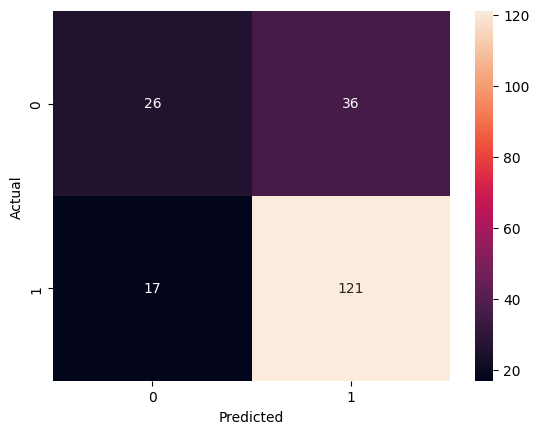

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## ROC-AUC Score

In [10]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.7536231884057972


## Feature Importance

In [14]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)
print(importance)

     Feature  Importance
4      hoehe    0.138115
0   laufkont    0.106259
1   laufzeit    0.106220
12     alter    0.101204
2      moral    0.063278
3       verw    0.061785
5   sparkont    0.049881
6    beszeit    0.049045
11      verm    0.042358
7       rate    0.041511
8     famges    0.037151
10  wohnzeit    0.036785
16     beruf    0.031521
14      wohn    0.028200
15  bishkred    0.026002
13  weitkred    0.020633
18     telef    0.020624
9     buerge    0.019212
17      pers    0.015530
19   gastarb    0.004688


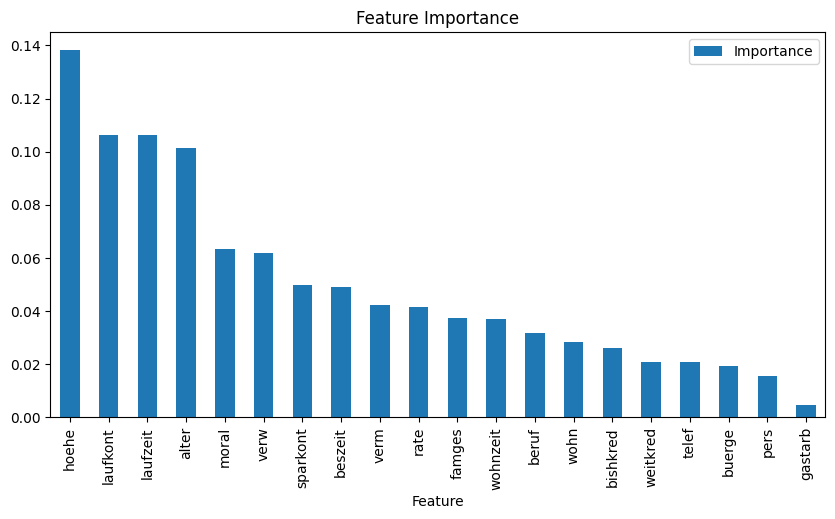

In [15]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10, 5)
)

plt.title("Feature Importance")
plt.show()

## Conclusion

A Random Forest Classifier was developed to predict customer creditworthiness.

The model achieved:

• Accuracy : 73.5%

• ROC-AUC : 0.754

The evaluation metrics indicate that the model performs well in distinguishing between good and bad credit applicants. Feature importance analysis showed that Loan Amount (hoehe), Account Status (laufkont), Loan Duration (laufzeit), Age (alter), and Credit History (moral) were among the most influential factors affecting predictions.

This project demonstrates how machine learning can assist financial institutions in assessing credit risk.
